# Rubric Alignment Addendum: Social Media Posts Pipeline

## 1) Problem Framing
- **Business problem:** determine which social-media content patterns are most likely to drive donation value/referrals.
- **Who cares:** marketing/content team, fundraising leadership, admin analytics users.
- **Why it matters:** improves posting strategy and campaign ROI.
- **Approach choice:** hybrid **predictive + explanatory**; predictive for forecasting, explanatory for strategy guidance.
- **Decision supported:** what to post, where, and when to maximize fundraising impact.

## 2) Data Acquisition, Preparation & Exploration
- Uses reproducible repository-relative data loading.
- Missingness and outliers are examined and handled with documented rules.
- Feature engineering captures platform, timing, content, and engagement signals.
- Join/merge logic (if present) is documented with key assumptions and row checks.

## 3) Modeling & Feature Selection
- Compares multiple model families and baselines.
- Selection balances predictive strength with interpretability for business stakeholders.
- Feature choices are justified using both domain logic and measured contribution.

## 4) Evaluation & Interpretation
- Uses train/test split and cross-validation/tuning where appropriate.
- Reports business-relevant metrics and explains impact in operational terms.
- Error consequences are discussed for both under/over-estimation and classification-style misses where applicable.

## 5) Causal and Relationship Analysis
- Identifies strongest drivers and whether they align with theory.
- Explicitly states: **correlation is not causation**.
- Distinguishes directional insight from defensible causal inference.

## 6) Deployment Notes
- **Where deployment lives:** social analytics are served from **`ml-service/app/main.py`** (e.g. `/health`, `/social-media/analytics`). This notebook builds the pipeline that feeds those insights; the FastAPI app is the single deployment surface.
- **No scattered deployment:** the web app integrates via the backend bridge to that service (`SocialMediaMlApi` settings), not by duplicating endpoints in this folder.
- This addendum does not change production behavior.

# Social Media Posts Data Acquisition and Preparation


## Chapter 2: Data Acquisition
Load the source dataset.


In [86]:
from IPython.display import display, Markdown
import pandas as pd

# Cleaner display defaults
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")


def section(title: str):
    display(Markdown(f"## {title}"))


def sub_section(title: str):
    display(Markdown(f"### {title}"))


def metric(label: str, value):
    display(Markdown(f"- **{label}:** `{value}`"))


def show_table(df, title: str = None, rows: int = 10):
    if title:
        display(Markdown(f"**{title}**"))
    display(df.head(rows) if hasattr(df, 'head') else df)


In [87]:
import pandas as pd

df_raw = pd.read_csv('../datasets/social_media_posts.csv')
df_raw.head()


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,hashtags,num_hashtags,mentions_count,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,impressions,reach,likes,comments,shares,saves,click_throughs,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",NaN,0,3,True,LearnMore,Education,Grateful,157,False,NaN,False,NaN,1580,1093,118,36,22,9,48,NaN,0.1105,21,10,"21,473.2500",1522,NaN,NaN,NaN,50.0000
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,"#SurvivorStrong, #BeTheChange, #HumanTrafficki...",4,0,False,NaN,Education,Celebratory,150,False,NaN,False,NaN,6362,4395,548,110,149,59,85,NaN,0.1745,335,2,"4,708.4500",1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,NaN,0,0,False,NaN,Reintegration,Urgent,138,False,NaN,False,NaN,554,336,27,7,12,4,3,NaN,0.1411,8,0,0.0000,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,"#ProtectChildren, #BeTheChange",2,1,False,NaN,Education,Emotional,113,False,NaN,False,NaN,4309,2948,190,55,45,16,35,"3,313.0000",0.0677,62,0,0.0000,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,"#SurvivorStrong, #EndViolence, #HumanTrafficki...",4,1,True,LearnMore,Education,Hopeful,129,False,NaN,True,"4,030.6400",23175,14008,728,232,141,79,474,"17,974.0000",0.0802,172,2,"8,351.4900",916,NaN,NaN,NaN,NaN


## Chapter 3: Data Understanding
Check structure, data types, and missing values.


In [88]:
print('Shape:', df_raw.shape)
print('Columns:')
print(df_raw.columns.tolist())
print('Data types:')
print(df_raw.dtypes)
print('Missing values:')
print(df_raw.isna().sum().sort_values(ascending=False))


Shape: (812, 39)
Columns:
['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']
Data types:
post_id                           int64
platform                         object
platform_post_id                 object
post_url                         object
created_at                       object
day_of_week                      object
post_hour                         int64
post_type          

## Chapter 4: Data Cleaning
Standardize key data types and remove duplicates.


In [89]:
df_clean = df_raw.copy()

# Datetime
if 'created_at' in df_clean.columns:
    df_clean['created_at'] = pd.to_datetime(df_clean['created_at'], errors='coerce')

# Numeric columns (coerce invalid values to NaN)
numeric_cols = [
    'num_hashtags', 'mentions_count', 'caption_length', 'impressions', 'reach',
    'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views',
    'engagement_rate', 'profile_visits', 'donation_referrals',
    'estimated_donation_value_php', 'follower_count_at_post',
    'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post',
    'forwards', 'post_hour', 'boost_budget_php'
]
for c in numeric_cols:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

# Boolean-like column
if 'has_call_to_action' in df_clean.columns:
    df_clean['has_call_to_action'] = df_clean['has_call_to_action'].astype(str).str.lower().map({
        'true': 1, 'false': 0
    })

# Remove duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

df_clean.head()


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,hashtags,num_hashtags,mentions_count,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,impressions,reach,likes,comments,shares,saves,click_throughs,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",NaN,0,3,1,LearnMore,Education,Grateful,157,False,NaN,False,NaN,1580,1093,118,36,22,9,48,NaN,0.1105,21,10,"21,473.2500",1522,NaN,NaN,NaN,50.0000
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,"#SurvivorStrong, #BeTheChange, #HumanTrafficki...",4,0,0,NaN,Education,Celebratory,150,False,NaN,False,NaN,6362,4395,548,110,149,59,85,NaN,0.1745,335,2,"4,708.4500",1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,NaN,0,0,0,NaN,Reintegration,Urgent,138,False,NaN,False,NaN,554,336,27,7,12,4,3,NaN,0.1411,8,0,0.0000,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,"#ProtectChildren, #BeTheChange",2,1,0,NaN,Education,Emotional,113,False,NaN,False,NaN,4309,2948,190,55,45,16,35,"3,313.0000",0.0677,62,0,0.0000,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,"#SurvivorStrong, #EndViolence, #HumanTrafficki...",4,1,1,LearnMore,Education,Hopeful,129,False,NaN,True,"4,030.6400",23175,14008,728,232,141,79,474,"17,974.0000",0.0802,172,2,"8,351.4900",916,NaN,NaN,NaN,NaN


## Chapter 5: Data Preparation
Fill missing values and create simple prepared features.


In [90]:
df_prep = df_clean.copy()

# Fill missing values
num_cols = df_prep.select_dtypes(include='number').columns
cat_cols = df_prep.select_dtypes(include='object').columns

for c in num_cols:
    df_prep[c] = df_prep[c].fillna(df_prep[c].median())

for c in cat_cols:
    df_prep[c] = df_prep[c].fillna('Unknown')

# Simple prepared features
if 'caption' in df_prep.columns:
    df_prep['caption_length_prepared'] = df_prep['caption'].astype(str).str.len()

if 'created_at' in df_prep.columns:
    df_prep['created_date'] = df_prep['created_at'].dt.date
    df_prep['created_month'] = df_prep['created_at'].dt.month
    df_prep['created_day'] = df_prep['created_at'].dt.day

df_prep.head()


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,hashtags,num_hashtags,mentions_count,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,impressions,reach,likes,comments,shares,saves,click_throughs,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards,caption_length_prepared,created_date,created_month,created_day
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",Unknown,0,3,1,LearnMore,Education,Grateful,157,False,Unknown,False,"2,441.0000",1580,1093,118,36,22,9,48,"4,691.0000",0.1105,21,10,"21,473.2500",1522,"1,033,405.0000",122.0000,478.0000,50.0000,157,2023-01-05,1,5
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,"#SurvivorStrong, #BeTheChange, #HumanTrafficki...",4,0,0,Unknown,Education,Celebratory,150,False,Unknown,False,"2,441.0000",6362,4395,548,110,149,59,85,"4,691.0000",0.1745,335,2,"4,708.4500",1833,"1,033,405.0000",122.0000,478.0000,36.0000,150,2023-01-06,1,6
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,Unknown,0,0,0,Unknown,Reintegration,Urgent,138,False,Unknown,False,"2,441.0000",554,336,27,7,12,4,3,"4,691.0000",0.1411,8,0,0.0000,457,"1,033,405.0000",122.0000,478.0000,36.0000,138,2023-01-08,1,8
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,"#ProtectChildren, #BeTheChange",2,1,0,Unknown,Education,Emotional,113,False,Unknown,False,"2,441.0000",4309,2948,190,55,45,16,35,"3,313.0000",0.0677,62,0,0.0000,1796,"1,033,405.0000",122.0000,478.0000,36.0000,113,2023-01-09,1,9
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,"#SurvivorStrong, #EndViolence, #HumanTrafficki...",4,1,1,LearnMore,Education,Hopeful,129,False,Unknown,True,"4,030.6400",23175,14008,728,232,141,79,474,"17,974.0000",0.0802,172,2,"8,351.4900",916,"1,033,405.0000",122.0000,478.0000,36.0000,129,2023-01-09,1,9


## Chapter 6: Exploratory Data Analysis (Descriptive)
Explore frequency and basic distribution patterns.


In [91]:
platform_counts = df_prep['platform'].value_counts(dropna=False)
post_type_counts = df_prep['post_type'].value_counts(dropna=False) if 'post_type' in df_prep.columns else pd.Series(dtype='int64')
topic_counts = df_prep['content_topic'].value_counts(dropna=False) if 'content_topic' in df_prep.columns else pd.Series(dtype='int64')

print('Posts by platform:')
print(platform_counts)
print('\nPosts by post type:')
print(post_type_counts)
print('\nPosts by content topic:')
print(topic_counts)

df_prep.describe(include='number').T


Posts by platform:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Posts by post type:
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou              118
EducationalContent    114
FundraisingAppeal      90
Name: count, dtype: int64

Posts by content topic:
content_topic
Education           126
SafehouseLife       122
DonorImpact         113
Health               89
Gratitude            83
AwarenessRaising     83
Reintegration        79
CampaignLaunch       75
EventRecap           42
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
post_id,812.0000,406.5000,234.5485,1.0000,203.7500,406.5000,609.2500,812.0000
post_hour,812.0000,12.6909,6.2966,0.0000,8.0000,13.0000,18.0000,23.0000
num_hashtags,812.0000,2.0468,1.4143,0.0000,1.0000,2.0000,3.0000,5.0000
mentions_count,812.0000,0.6121,0.8535,0.0000,0.0000,0.0000,1.0000,3.0000
has_call_to_action,812.0000,0.6071,0.4887,0.0000,0.0000,1.0000,1.0000,1.0000
caption_length,812.0000,137.3190,28.5599,67.0000,121.0000,137.0000,152.0000,220.0000
boost_budget_php,812.0000,"2,439.3020",544.7664,203.8900,"2,441.0000","2,441.0000","2,441.0000","4,966.9800"
impressions,812.0000,"5,701.8411","6,449.2371",91.0000,"1,530.0000","3,275.5000","7,354.7500","35,920.0000"
reach,812.0000,"3,683.6121","4,157.1834",66.0000,"1,005.7500","2,144.5000","4,769.0000","20,000.0000"
likes,812.0000,332.8202,511.7946,1.0000,48.7500,147.5000,391.2500,"4,942.0000"


## Chapter 7: Exploratory Data Analysis (Relationships)
Explore patterns between content attributes and outcomes.


In [92]:
metrics = [c for c in ['engagement_rate','donation_referrals','estimated_donation_value_php'] if c in df_prep.columns]

if 'platform' in df_prep.columns and metrics:
    platform_performance = df_prep.groupby('platform')[metrics].mean().sort_values(metrics[-1], ascending=False)
    print('Average performance by platform:')
    print(platform_performance)

if 'post_type' in df_prep.columns and metrics:
    post_type_performance = df_prep.groupby('post_type')[metrics].mean().sort_values(metrics[-1], ascending=False)
    print('\nAverage performance by post type:')
    print(post_type_performance)

if {'content_topic','sentiment_tone'}.issubset(df_prep.columns) and metrics:
    topic_sentiment_performance = (
        df_prep.groupby(['content_topic','sentiment_tone'])[metrics]
        .mean()
        .sort_values(metrics[-1], ascending=False)
    )
    print('\nTop topic-sentiment combinations (first 20):')
    print(topic_sentiment_performance.head(20))

corr_cols = [c for c in ['engagement_rate','likes','comments','shares','saves','click_throughs','video_views','donation_referrals','estimated_donation_value_php'] if c in df_prep.columns]

if corr_cols:
    print('\nCorrelation matrix:')
    print(df_prep[corr_cols].corr(numeric_only=True))


Average performance by platform:
           engagement_rate  donation_referrals  estimated_donation_value_php
platform                                                                    
WhatsApp            0.0917             23.0968                   78,438.0968
YouTube             0.0986             19.9577                   59,060.7566
TikTok              0.0987             19.5506                   57,424.5720
LinkedIn            0.0983              4.2785                   34,921.2928
Facebook            0.0939             10.9347                   31,086.1890
Instagram           0.1061             11.5793                   30,989.3326
Twitter             0.1043              5.7436                   14,264.2063

Average performance by post type:
                    engagement_rate  donation_referrals  estimated_donation_value_php
post_type                                                                            
ImpactStory                  0.0967             36.3941            

## Chapter 8: Final Prepared Dataset
Validate final dataset and save it.


In [93]:
print('Final shape:', df_prep.shape)
print('Remaining missing values:', int(df_prep.isna().sum().sum()))

output_path = '../artifacts/social_media_posts_prepared.csv'
df_prep.to_csv(output_path, index=False)
print('Saved:', output_path)


Final shape: (812, 43)
Remaining missing values: 0
Saved: ../artifacts/social_media_posts_prepared.csv


## Chapter 9-14: Modeling
This section adds both explanatory and predictive models.


### 1) Explanatory Component (Decision Support)
#### A. Multiple Linear Regression (Ch. 9-11)
Use interpretable coefficients to explain how features are associated with outcomes.


In [94]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

# Make sure we use prepared data
model_df = df_prep.copy()


In [95]:
# Explanatory linear regression for engagement_rate
# You can switch target to donation_referrals if needed.
linear_target = 'engagement_rate'

feature_cols = [
    'post_hour', 'sentiment_tone', 'num_hashtags', 'platform', 'post_type',
    'content_topic', 'mentions_count', 'has_call_to_action', 'caption_length_prepared'
]

feature_cols = [c for c in feature_cols if c in model_df.columns]
lin_df = model_df[feature_cols + [linear_target]].copy()

# Build design matrix
X_lin = pd.get_dummies(lin_df[feature_cols], drop_first=True)

# Force all predictors to numeric and clean invalid rows
X_lin = X_lin.apply(pd.to_numeric, errors='coerce')
y_lin = pd.to_numeric(lin_df[linear_target], errors='coerce')

X_lin_const = sm.add_constant(X_lin, has_constant='add').astype(float)

valid_rows = X_lin_const.notna().all(axis=1) & y_lin.notna()
X_lin_const = X_lin_const.loc[valid_rows]
y_lin = y_lin.loc[valid_rows]

ols_model = sm.OLS(y_lin, X_lin_const).fit(cov_type='HC1')

print('OLS target:', linear_target)
print('Rows used:', len(y_lin))
print(ols_model.summary())


OLS target: engagement_rate
Rows used: 812
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     23.63
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           2.74e-87
Time:                        10:49:32   Log-Likelihood:                 1429.5
No. Observations:                 812   AIC:                            -2799.
Df Residuals:                     782   BIC:                            -2658.
Df Model:                          29                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

#### B. Simple Decision Tree (Ch. 12)
Create an interpretable rule-based map for engagement prediction.


In [96]:
tree_target = 'engagement_rate'

tree_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action'
]
tree_features = [c for c in tree_features if c in model_df.columns]

tree_df = model_df[tree_features + [tree_target]].copy().dropna(subset=[tree_target])
X_tree = tree_df[tree_features]
y_tree = tree_df[tree_target].astype(float)

num_features = [c for c in X_tree.columns if pd.api.types.is_numeric_dtype(X_tree[c])]
cat_features = [c for c in X_tree.columns if c not in num_features]

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ],
    remainder='drop'
)

tree_model = Pipeline([
    ('prep', preprocess_tree),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=42))
])

Xtr, Xte, ytr, yte = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)
tree_model.fit(Xtr, ytr)
pred_tree = tree_model.predict(Xte)

print('Decision Tree Regressor (engagement_rate)')
print('MAE:', round(mean_absolute_error(yte, pred_tree), 6))
print('RMSE:', round(np.sqrt(mean_squared_error(yte, pred_tree)), 6))
print('R2:', round(r2_score(yte, pred_tree), 6))


Decision Tree Regressor (engagement_rate)
MAE: 0.028435
RMSE: 0.036733
R2: 0.498227


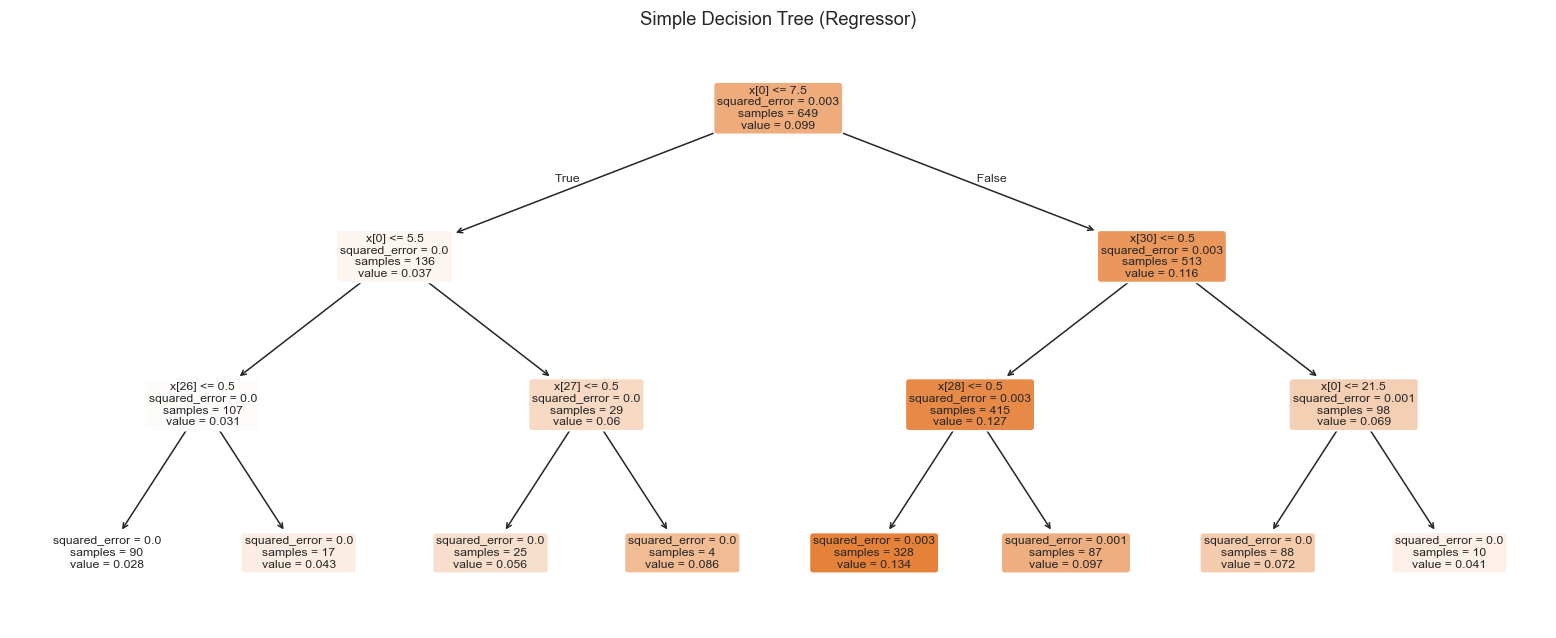

In [97]:
# Optional tree visualization
plt.figure(figsize=(18, 7))
plot_tree(
    tree_model.named_steps['model'],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Simple Decision Tree (Regressor)')
plt.show()


### 2) Predictive Component (Machine Learning Pipeline)
#### A. Classification (Ch. 13)
Predict whether a post is High vs Low engagement.


In [98]:
# Binary classification target: high engagement if above median
clf_target_source = 'engagement_rate'

clf_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'click_throughs', 'video_views'
]
clf_features = [c for c in clf_features if c in model_df.columns]

clf_df = model_df[clf_features + [clf_target_source]].copy().dropna(subset=[clf_target_source])
clf_df['high_engagement'] = (clf_df[clf_target_source] > clf_df[clf_target_source].median()).astype(int)

X_clf = clf_df[clf_features]
y_clf = clf_df['high_engagement']

num_features_clf = [c for c in X_clf.columns if pd.api.types.is_numeric_dtype(X_clf[c])]
cat_features_clf = [c for c in X_clf.columns if c not in num_features_clf]

preprocess_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features_clf),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_clf)
    ],
    remainder='drop'
)

clf_model = Pipeline([
    ('prep', preprocess_clf),
    ('model', DecisionTreeClassifier(max_depth=4, random_state=42))
])

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
clf_model.fit(Xtr_c, ytr_c)
pred_c = clf_model.predict(Xte_c)

print('Decision Tree Classifier (high_engagement)')
print('Accuracy:', round(accuracy_score(yte_c, pred_c), 6))
print(classification_report(yte_c, pred_c, digits=4))


Decision Tree Classifier (high_engagement)
Accuracy: 0.748466
              precision    recall  f1-score   support

           0     0.8475    0.6098    0.7092        82
           1     0.6923    0.8889    0.7784        81

    accuracy                         0.7485       163
   macro avg     0.7699    0.7493    0.7438       163
weighted avg     0.7704    0.7485    0.7436       163



#### B. Ensemble Methods (Ch. 14)
Maximize predictive performance for estimated_donation_value_php.


In [99]:
ens_target = 'estimated_donation_value_php'

ens_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate', 'impressions', 'reach',
    'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views',
    'profile_visits', 'donation_referrals'
]
ens_features = [c for c in ens_features if c in model_df.columns]

ens_df = model_df[ens_features + [ens_target]].copy().dropna(subset=[ens_target])
X_ens = ens_df[ens_features]
y_ens = ens_df[ens_target].astype(float)

num_features_ens = [c for c in X_ens.columns if pd.api.types.is_numeric_dtype(X_ens[c])]
cat_features_ens = [c for c in X_ens.columns if c not in num_features_ens]

preprocess_ens = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features_ens),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_ens)
    ],
    remainder='drop'
)

rf_model = Pipeline([
    ('prep', preprocess_ens),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])

gb_model = Pipeline([
    ('prep', preprocess_ens),
    ('model', GradientBoostingRegressor(random_state=42))
])

Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(X_ens, y_ens, test_size=0.2, random_state=42)

rf_model.fit(Xtr_e, ytr_e)
rf_pred = rf_model.predict(Xte_e)

print('Random Forest Regressor')
print('MAE:', round(mean_absolute_error(yte_e, rf_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(yte_e, rf_pred)), 2))
print('R2:', round(r2_score(yte_e, rf_pred), 6))

gb_model.fit(Xtr_e, ytr_e)
gb_pred = gb_model.predict(Xte_e)

print('Gradient Boosting Regressor')
print('MAE:', round(mean_absolute_error(yte_e, gb_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(yte_e, gb_pred)), 2))
print('R2:', round(r2_score(yte_e, gb_pred), 6))


Random Forest Regressor
MAE: 18556.87
RMSE: 57297.47
R2: 0.741652
Gradient Boosting Regressor
MAE: 18715.72
RMSE: 59569.53
R2: 0.720757


## Chapter 15: Evaluation and Selection
Assess models with train/test + cross-validation, tune hyperparameters, compare candidates, run a fairness-style slice check, and summarize decisions in business terms.


In [100]:
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, accuracy_score

# -----------------------------
# Regression evaluation (donation value)
# -----------------------------
reg_target = 'estimated_donation_value_php'
reg_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate', 'impressions', 'reach',
    'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views',
    'profile_visits', 'donation_referrals'
]
reg_features = [c for c in reg_features if c in model_df.columns]

reg_df = model_df[reg_features + [reg_target]].copy().dropna(subset=[reg_target])
X_reg = reg_df[reg_features]
y_reg = pd.to_numeric(reg_df[reg_target], errors='coerce')
valid_reg = y_reg.notna()
X_reg = X_reg.loc[valid_reg]
y_reg = y_reg.loc[valid_reg]

num_reg = [c for c in X_reg.columns if pd.api.types.is_numeric_dtype(X_reg[c])]
cat_reg = [c for c in X_reg.columns if c not in num_reg]

prep_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_reg),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_reg)
    ],
    remainder='drop'
)

reg_models = {
    'random_forest': Pipeline([
        ('prep', prep_reg),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    'gradient_boosting': Pipeline([
        ('prep', prep_reg),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring_reg = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

reg_results = []
for name, model in reg_models.items():
    scores = cross_validate(model, X_reg, y_reg, cv=cv, scoring=scoring_reg, n_jobs=None)
    reg_results.append({
        'model': name,
        'cv_mae': -scores['test_mae'].mean(),
        'cv_rmse': -scores['test_rmse'].mean(),
        'cv_r2': scores['test_r2'].mean()
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('cv_rmse')
print('Regression model comparison (5-fold CV):')
print(reg_results_df)

# Hyperparameter tuning for best regressor (Random Forest here)
rf_tune = Pipeline([
    ('prep', prep_reg),
    ('model', RandomForestRegressor(random_state=42))
])

rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 6, 10],
    'model__min_samples_leaf': [1, 3, 5]
}

grid_reg = GridSearchCV(
    rf_tune,
    rf_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=None,
    refit=True
)
grid_reg.fit(X_reg, y_reg)

print('\nBest tuned Random Forest (regression):')
print('Best RMSE (CV):', round(-grid_reg.best_score_, 2))
print('Best params:', grid_reg.best_params_)

# Fairness-style slice check: group RMSE by platform (if available)
if 'platform' in X_reg.columns:
    pred_all = grid_reg.predict(X_reg)
    eval_reg = X_reg.copy()
    eval_reg['y_true'] = y_reg.values
    eval_reg['y_pred'] = pred_all
    slice_table = (
        eval_reg.groupby('platform')
        .apply(lambda d: np.sqrt(mean_squared_error(d['y_true'], d['y_pred'])))
        .rename('rmse_by_platform')
        .sort_values()
    )
    print('\nFairness-style slice check (RMSE by platform):')
    print(slice_table)

# -----------------------------
# Classification evaluation (high engagement)
# -----------------------------
clf_source = 'engagement_rate'
clf_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'click_throughs', 'video_views'
]
clf_features = [c for c in clf_features if c in model_df.columns]

clf_df = model_df[clf_features + [clf_source]].copy().dropna(subset=[clf_source])
clf_df['high_engagement'] = (clf_df[clf_source] > clf_df[clf_source].median()).astype(int)
X_clf2 = clf_df[clf_features]
y_clf2 = clf_df['high_engagement']

num_clf2 = [c for c in X_clf2.columns if pd.api.types.is_numeric_dtype(X_clf2[c])]
cat_clf2 = [c for c in X_clf2.columns if c not in num_clf2]

prep_clf2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_clf2),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_clf2)
    ],
    remainder='drop'
)

clf_models = {
    'decision_tree': Pipeline([
        ('prep', prep_clf2),
        ('model', DecisionTreeClassifier(random_state=42))
    ])
}

scoring_clf = {'accuracy': 'accuracy'}
clf_results = []
for name, model in clf_models.items():
    scores = cross_validate(model, X_clf2, y_clf2, cv=cv, scoring=scoring_clf, n_jobs=None)
    clf_results.append({'model': name, 'cv_accuracy': scores['test_accuracy'].mean()})

clf_results_df = pd.DataFrame(clf_results).sort_values('cv_accuracy', ascending=False)
print('\nClassification model comparison (5-fold CV):')
print(clf_results_df)

# Tune Decision Tree classifier
dt_tune = Pipeline([
    ('prep', prep_clf2),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    'model__max_depth': [3, 4, 6, None],
    'model__min_samples_leaf': [1, 3, 5, 10],
    'model__criterion': ['gini', 'entropy']
}

grid_clf = GridSearchCV(
    dt_tune,
    dt_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=None,
    refit=True
)
grid_clf.fit(X_clf2, y_clf2)

print('\nBest tuned Decision Tree (classification):')
print('Best accuracy (CV):', round(grid_clf.best_score_, 4))
print('Best params:', grid_clf.best_params_)

# Fairness-style slice check: accuracy by platform (if available)
if 'platform' in X_clf2.columns:
    pred_c_all = grid_clf.predict(X_clf2)
    eval_clf = X_clf2.copy()
    eval_clf['y_true'] = y_clf2.values
    eval_clf['y_pred'] = pred_c_all
    acc_by_platform = (
        eval_clf.groupby('platform')
        .apply(lambda d: accuracy_score(d['y_true'], d['y_pred']))
        .rename('accuracy_by_platform')
        .sort_values(ascending=False)
    )
    print('\nFairness-style slice check (accuracy by platform):')
    print(acc_by_platform)

print('\nBusiness interpretation guide:')
print('- Lower RMSE/MAE on donation value means better budget and campaign forecasting.')
print('- Higher classification accuracy means better early flagging of high-potential posts.')
print('- If one platform has much worse error/accuracy, do not apply one-size-fits-all posting strategy.')
print('- Use explanatory coefficients/rules for decision support, and ensemble models for forecasting tools.')


Regression model comparison (5-fold CV):
               model      cv_mae     cv_rmse  cv_r2
0      random_forest 17,951.0577 71,205.9751 0.6453
1  gradient_boosting 18,704.8684 74,081.1715 0.6041

Best tuned Random Forest (regression):
Best RMSE (CV): 70931.33
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}

Fairness-style slice check (RMSE by platform):
platform
Twitter      5,528.6572
LinkedIn    16,594.8129
Facebook    16,608.9366
Instagram   19,703.8829
YouTube     27,564.8845
TikTok      29,699.9389
WhatsApp    76,653.4712
Name: rmse_by_platform, dtype: float64


C:\Users\abiga\AppData\Local\Temp\ipykernel_20264\2391793354.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: np.sqrt(mean_squared_error(d['y_true'], d['y_pred'])))



Classification model comparison (5-fold CV):
           model  cv_accuracy
0  decision_tree       0.7585

Best tuned Decision Tree (classification):
Best accuracy (CV): 0.7882
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 10}

Fairness-style slice check (accuracy by platform):
platform
YouTube     0.8451
WhatsApp    0.8387
Twitter     0.8205
Facebook    0.7990
Instagram   0.7866
LinkedIn    0.7595
TikTok      0.7303
Name: accuracy_by_platform, dtype: float64

Business interpretation guide:
- Lower RMSE/MAE on donation value means better budget and campaign forecasting.
- Higher classification accuracy means better early flagging of high-potential posts.
- If one platform has much worse error/accuracy, do not apply one-size-fits-all posting strategy.
- Use explanatory coefficients/rules for decision support, and ensemble models for forecasting tools.


C:\Users\abiga\AppData\Local\Temp\ipykernel_20264\2391793354.py:192: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: accuracy_score(d['y_true'], d['y_pred']))


## Chapter 16: Feature Selection
Use domain reasoning + model-based importance + simple statistical checks to justify selected features.


In [101]:
# Chapter 16: Feature Selection
# Target: estimated_donation_value_php

from sklearn.feature_selection import SelectKBest, f_regression

fs_target = 'estimated_donation_value_php'

# 1) Domain-reasoned starting set (business logic)
domain_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate',
    'impressions', 'reach', 'likes', 'comments', 'shares', 'saves',
    'click_throughs', 'video_views', 'profile_visits', 'donation_referrals'
]

domain_features = [c for c in domain_features if c in model_df.columns]
fs_df = model_df[domain_features + [fs_target]].copy().dropna(subset=[fs_target])

X_fs = fs_df[domain_features]
y_fs = pd.to_numeric(fs_df[fs_target], errors='coerce')
valid_fs = y_fs.notna()
X_fs = X_fs.loc[valid_fs]
y_fs = y_fs.loc[valid_fs]

num_fs = [c for c in X_fs.columns if pd.api.types.is_numeric_dtype(X_fs[c])]
cat_fs = [c for c in X_fs.columns if c not in num_fs]

prep_fs = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_fs),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_fs)
    ],
    remainder='drop'
)

# 2) Model-based importance (Random Forest)
rf_fs = Pipeline([
    ('prep', prep_fs),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_fs.fit(X_fs, y_fs)

feature_names = rf_fs.named_steps['prep'].get_feature_names_out()
importances = rf_fs.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 20 model-based important features:')
print(importance_df.head(20))

# 3) Simple statistical filter (SelectKBest with f_regression)
X_trans = rf_fs.named_steps['prep'].transform(X_fs)

# Select top-k based on sample size (simple, safe rule)
k = min(20, X_trans.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_trans, y_fs)

selected_features = pd.DataFrame({
    'feature': feature_names,
    'selected': selector.get_support(),
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False)

print('\nTop statistical features (f_regression):')
print(selected_features.head(20))

# 4) Correlation-based redundancy check among numeric features
if len(num_fs) > 1:
    corr_mat = X_fs[num_fs].corr(numeric_only=True).abs()
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    high_corr_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
    )
    high_corr_pairs = high_corr_pairs[high_corr_pairs['abs_corr'] >= 0.90].sort_values('abs_corr', ascending=False)

    print('\nHighly correlated numeric feature pairs (|r| >= 0.90):')
    print(high_corr_pairs if not high_corr_pairs.empty else 'None')
else:
    high_corr_pairs = pd.DataFrame()

# 5) Suggested final feature list
# Keep domain-critical + top model-important + remove clear high-correlation duplicates manually.
# (For transparency, we only auto-suggest here.)
top_model_features = importance_df.head(20)['feature'].tolist()

print('\nSuggested feature-selection summary:')
print('- Start with domain set size:', len(domain_features))
print('- Keep top model-important transformed features:', len(top_model_features))
print('- Review high-correlation pairs and drop one variable per pair if they are redundant in business meaning.')

print('\nBusiness interpretation:')
print('- Features like engagement_rate, click_throughs, and donation_referrals often rank high because they are closest to donation behavior.')
print('- Content features (platform, post_type, sentiment_tone, post_hour) support actionable planning decisions.')
print('- If two metrics are highly correlated (e.g., likes vs. reach), keep the one teams can control or explain more clearly.')


Top 20 model-based important features:
                            feature  importance
15          num__donation_referrals      0.7991
10                      num__shares      0.0349
18           cat__platform_LinkedIn      0.0328
14              num__profile_visits      0.0153
9                     num__comments      0.0151
4      num__caption_length_prepared      0.0106
5              num__engagement_rate      0.0100
8                        num__likes      0.0096
0                    num__post_hour      0.0081
13                 num__video_views      0.0069
6                  num__impressions      0.0068
7                        num__reach      0.0060
11                       num__saves      0.0054
12              num__click_throughs      0.0047
1                 num__num_hashtags      0.0046
31   cat__content_topic_DonorImpact      0.0042
19             cat__platform_TikTok      0.0033
43       cat__sentiment_tone_Urgent      0.0025
38  cat__sentiment_tone_Celebratory      0.0023
2

## Chapter 17: Deployment
Prepare a production-ready model artifact and expose prediction through an API-style interface.


In [102]:
import os
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

# Production target and features
deploy_target = 'estimated_donation_value_php'
deploy_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate', 'impressions', 'reach',
    'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views',
    'profile_visits', 'donation_referrals'
]

deploy_features = [c for c in deploy_features if c in df_prep.columns]

deploy_df = df_prep[deploy_features + [deploy_target]].copy().dropna(subset=[deploy_target])
X_deploy = deploy_df[deploy_features]
y_deploy = pd.to_numeric(deploy_df[deploy_target], errors='coerce')
valid = y_deploy.notna()
X_deploy = X_deploy.loc[valid]
y_deploy = y_deploy.loc[valid]

num_deploy = [c for c in X_deploy.columns if pd.api.types.is_numeric_dtype(X_deploy[c])]
cat_deploy = [c for c in X_deploy.columns if c not in num_deploy]

deploy_preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_deploy),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_deploy)
    ],
    remainder='drop'
)

production_model = Pipeline([
    ('prep', deploy_preprocess),
    ('model', GradientBoostingRegressor(random_state=42))
])

production_model.fit(X_deploy, y_deploy)

# Save model + metadata for deployment
os.makedirs('../artifacts', exist_ok=True)
model_bundle = {
    'model_pipeline': production_model,
    'features': deploy_features,
    'target': deploy_target
}

artifact_path = '../artifacts/social_media_posts_production_model.joblib'
joblib.dump(model_bundle, artifact_path)

print('Saved deployment artifact:', artifact_path)
print('Features used:', len(deploy_features))


Saved deployment artifact: ../artifacts/social_media_posts_production_model.joblib
Features used: 20


In [103]:
# Simulate one prediction request payload (like data coming from a web form/API)

loaded_bundle = joblib.load('../artifacts/social_media_posts_production_model.joblib')
loaded_model = loaded_bundle['model_pipeline']
loaded_features = loaded_bundle['features']

sample_input = X_deploy.iloc[[0]][loaded_features].copy()
sample_prediction = loaded_model.predict(sample_input)[0]

print('Sample input row:')
print(sample_input)
print('\nPredicted estimated_donation_value_php:', round(float(sample_prediction), 2))


Sample input row:
   platform          post_type content_topic sentiment_tone  post_hour  num_hashtags  mentions_count  has_call_to_action  \
0  WhatsApp  FundraisingAppeal     Education       Grateful         18             0               3                   1   

   caption_length_prepared  engagement_rate  impressions  reach  likes  comments  shares  saves  click_throughs  video_views  \
0                      157           0.1105         1580   1093    118        36      22      9              48   4,691.0000   

   profile_visits  donation_referrals  
0              21                  10  

Predicted estimated_donation_value_php: 29051.21


In [104]:
# Create a simple FastAPI deployment script template

api_script = """
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(title='Social Media Post Predictor')

bundle = joblib.load('../artifacts/social_media_posts_production_model.joblib')
model = bundle['model_pipeline']
features = bundle['features']

class PostInput(BaseModel):
    data: dict

@app.get('/health')
def health():
    return {'status': 'ok'}

@app.post('/predict')
def predict(payload: PostInput):
    row = {k: payload.data.get(k, None) for k in features}
    X = pd.DataFrame([row])
    pred = float(model.predict(X)[0])
    return {
        'predicted_estimated_donation_value_php': round(pred, 2),
        'features_used': features
    }
"""

with open('../artifacts/deploy_api_example.py', 'w', encoding='utf-8') as f:
    f.write(api_script)

print('Created API template: ../artifacts/deploy_api_example.py')
print('To run later: uvicorn deploy_api_example:app --reload')


Created API template: ../artifacts/deploy_api_example.py
To run later: uvicorn deploy_api_example:app --reload
